# Phase 2 - Baseline Audibilization

**Goal**: render two WAV files of the clean event stream so I can hear the difference between:
- unflistered: every detected bubble triggers a sound 
- current filter: only selected==1 bubbles trigger a sound 

Each instrument group is mapped to a fixed pitch, and each event is rendered as a short sine click

## 2.0 Setup

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
import matplotlib.pyplot as plt

DATA_CLEAN_DIR  = '../data_clean'
OUTPUT_AUDIO_DIR = '../outputs/audio'
os.makedirs(OUTPUT_AUDIO_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_clean.csv'))
print(f'Loaded {len(df):,} events')
print(f'Selected: {(df["selected"]==1).sum():,}')
print(f'In anomaly: {df["in_anomaly"].sum():,}')


Loaded 9,483 events
Selected: 2,244
In anomaly: 5,171


## 2.1 Filter out anomalous events

In [3]:
df_clean = df[~df['in_anomaly']].reset_index(drop=True)
df_clean_sel = df_clean[df_clean['selected']==1].reset_index(drop=True)

print(f'Clean (no anomaly):{len(df_clean):,} events')
print(f'Clean selected:{len(df_clean_sel):,} events')
print(f'Session duration:{df_clean["t_rel"].max():.1f} sec '
      f'({df_clean["t_rel"].max()/60:.1f} min)')

Clean (no anomaly):4,312 events
Clean selected:2,238 events
Session duration:16008.0 sec (266.8 min)


## 2.2 Audio rendering
Using skills that I learned in my previous project.

In [6]:
# ============ Settings ============
SR = 44100
DUR = 0.1

GROUP_FREQ = {
    'biwa':   220.0,   # A3
    'koto':   330.0,   # E4
    'kakko':  880.0,   # A5
    'taiko':  110.0,   # A2
    'shoko':  660.0,   # E5
}

# ============ Render function ============
def render(events_df, out_path, total_duration):
    """Render events as sine clicks into a WAV file."""
    
    # 1. Make a silent track (all zeros)
    n_samples = int(total_duration * SR)
    track = np.zeros(n_samples)
    
    # 2. Time axis for one click
    t_click = np.linspace(0, DUR, int(SR * DUR))
    
    # 3. For each event, add a sine wave at its time
    for i in range(len(events_df)):
        ev = events_df.iloc[i]
        
        # Pick frequency based on instrument group
        freq = GROUP_FREQ.get(ev['group'], 440.0)
        
        # Make sine wave
        click = np.sin(2 * np.pi * freq * t_click)
        
        # Adjust volume by bubble size
        volume = ev['area'] / 30.0
        if volume > 1.0:
            volume = 1.0
        click = click * volume
        
        # Place the click in the full track
        start_sample = int(ev['t_rel'] * SR)
        end_sample = start_sample + len(click)
        if end_sample <= n_samples:
            track[start_sample:end_sample] = track[start_sample:end_sample] + click
    
    # 4. Save as WAV
    # Scale to int16 range for WAV format
    track_int = (track * 5000).astype(np.int16)
    wavfile.write(out_path, SR, track_int)
    print(f'Saved: {out_path}')
    return track


# ============ Render both versions ============
total_dur = df_clean['t_rel'].max() + 1

wav_unfiltered = os.path.join(OUTPUT_AUDIO_DIR, 'unfiltered.wav')
wav_current    = os.path.join(OUTPUT_AUDIO_DIR, 'current_filter.wav')

print('Rendering unfiltered...')
track_unf = render(df_clean, wav_unfiltered, total_dur)

print('Rendering current filter...')
track_cur = render(df_clean_sel, wav_current, total_dur)

Rendering unfiltered...
Saved: ../outputs/audio/unfiltered.wav
Rendering current filter...
Saved: ../outputs/audio/current_filter.wav


## 2.3 Quick visual comparison of the waveforms

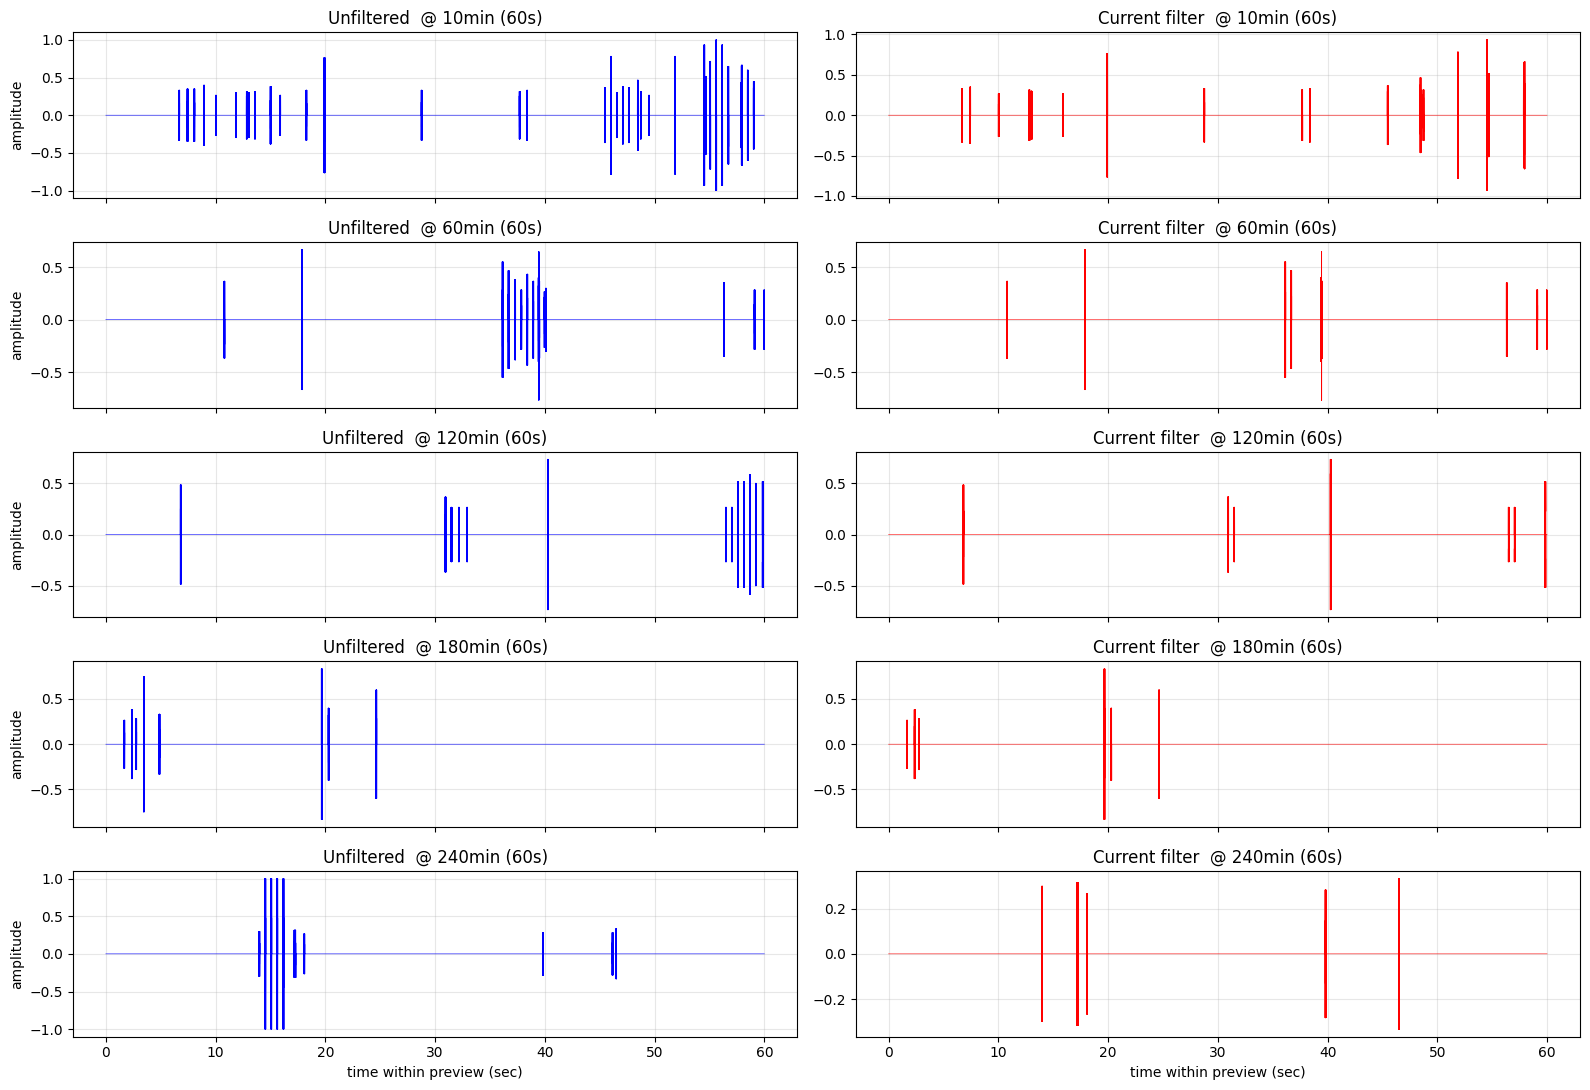


Event counts in preview windows:
   10min ~  11.0min : unfiltered=  35, selected= 18
   60min ~  61.0min : unfiltered=  15, selected=  9
  120min ~ 121.0min : unfiltered=  13, selected=  7
  180min ~ 181.0min : unfiltered=   9, selected=  6
  240min ~ 241.0min : unfiltered=  11, selected=  6


In [10]:
# Show waveforms at multiple times to compare different fermentation phases
preview_sec = 60   # 2-minute preview windows

# Choose times to inspect (in minutes from session start)
preview_times_min = [10, 60, 120, 180, 240]   # 10min, 1h, 2h, 3h, 4h

fig, axes = plt.subplots(len(preview_times_min), 2, figsize=(16, 2.2 * len(preview_times_min)),
                          sharex='col')

for row, start_min in enumerate(preview_times_min):
    start_sample = int(start_min * 60 * SR)
    end_sample = start_sample + preview_sec * SR
    
    # Make sure we don't go past the track length
    if end_sample > len(track_unf):
        print(f'  Skipping {start_min}min: beyond track length')
        continue
    
    # Time axis (relative to start of this preview)
    t_axis = np.arange(end_sample - start_sample) / SR
    
    # Unfiltered
    axes[row, 0].plot(t_axis, track_unf[start_sample:end_sample],
                       lw=0.4, color='blue')
    axes[row, 0].set_ylabel('amplitude')
    axes[row, 0].set_title(f'Unfiltered  @ {start_min}min ({preview_sec}s)')
    axes[row, 0].grid(alpha=0.3)
    
    # Current filter
    axes[row, 1].plot(t_axis, track_cur[start_sample:end_sample],
                       lw=0.4, color='red')
    axes[row, 1].set_title(f'Current filter  @ {start_min}min ({preview_sec}s)')
    axes[row, 1].grid(alpha=0.3)

# Bottom row: x-axis label
axes[-1, 0].set_xlabel('time within preview (sec)')
axes[-1, 1].set_xlabel('time within preview (sec)')

plt.tight_layout()
plt.savefig('../outputs/plots/08_waveform_preview.png', dpi=120)
plt.show()

# Print event counts in each preview window for context
print('\nEvent counts in preview windows:')
for start_min in preview_times_min:
    end_min = start_min + preview_sec / 60
    n_unf = ((df_clean['t_rel'] >= start_min*60) &
             (df_clean['t_rel'] <  end_min*60)).sum()
    n_sel = ((df_clean_sel['t_rel'] >= start_min*60) &
             (df_clean_sel['t_rel'] <  end_min*60)).sum()
    print(f'  {start_min:>3}min ~ {end_min:>5.1f}min : '
          f'unfiltered={n_unf:>4}, selected={n_sel:>3}')

## Finding
It seems that the current filter partly represents the rhythm but it doesn't capture the rhythm when fermentation is active.